<a href="https://colab.research.google.com/github/fianbio/AI-driven-PLA2-antivenome/blob/main/04_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q rdkit scikit-learn xgboost joblib pandas numpy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = '/content/drive/MyDrive/pla2'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, 'final_model.joblib')
approved_features_path = os.path.join(DATA_DIR, 'approved_drugs_features.npz')
approved_metadata_path = os.path.join(DATA_DIR, 'approved_drugs_metadata.csv')
training_metadata_path = os.path.join(DATA_DIR, 'training_metadata.csv')

for p in [model_path, approved_features_path, approved_metadata_path, training_metadata_path]:
    print(p, '- exists:', os.path.exists(p))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/pla2/models/final_model.joblib - exists: True
/content/drive/MyDrive/pla2/data/approved_drugs_features.npz - exists: True
/content/drive/MyDrive/pla2/data/approved_drugs_metadata.csv - exists: True
/content/drive/MyDrive/pla2/data/training_metadata.csv - exists: True


In [ ]:
import json
import joblib
import numpy as np
import pandas as pd

final_model = joblib.load(model_path)

In [ ]:
approved_features = np.load(approved_features_path)
approved_metadata_df = pd.read_csv(approved_metadata_path)
training_metadata_df = pd.read_csv(training_metadata_path)

print('Jumlah approved drugs:', len(approved_metadata_df))

Jumlah approved drugs: 3413


In [ ]:
X_approved = approved_features['X_combined']

In [ ]:
pred_proba = final_model.predict_proba(X_approved)[:, 1]
pred_label = final_model.predict(X_approved)

screening_df = approved_metadata_df.copy()
screening_df['pred_proba_active'] = pred_proba
screening_df['pred_label'] = pred_label

screening_df = screening_df.sort_values('pred_proba_active', ascending=False).reset_index(drop=True)

print(f'Total approved drugs diprediksi: {len(screening_df)}')
print(f'Diprediksi aktif (label=1): {(screening_df["pred_label"] == 1).sum()}')
print(f'Diprediksi inaktif (label=0): {(screening_df["pred_label"] == 0).sum()}')

screening_df.head(20)

Total approved drugs diprediksi: 3413
Diprediksi aktif (label=1): 108
Diprediksi inaktif (label=0): 3305


,molecule_chembl_id,pref_name,canonical_smiles,pred_proba_active,pred_label
0,CHEMBL5314588,PERFLUOROHEXYLOCTANE,CCCCCCCCC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F...,0.674793,1
1,CHEMBL1200733,DESFLURANE,FC(F)OC(F)C(F)(F)F,0.672441,1
2,CHEMBL1200694,SEVOFLURANE,FCOC(C(F)(F)F)C(F)(F)F,0.652300,1
3,CHEMBL1200607,PERFLEXANE,FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,0.651572,1
4,CHEMBL1899801,PERFLENAPENT,FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,0.644724,1
5,CHEMBL1256,ISOFLURANE,FC(F)OC(Cl)C(F)(F)F,0.643084,1
6,CHEMBL1663,PERFLUTREN,FC(F)(F)C(F)(F)C(F)(F)F,0.641731,1
7,CHEMBL1257,ENFLURANE,FC(F)OC(F)(F)C(F)Cl,0.623508,1
8,CHEMBL1200866,PERFLUBRON,FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F...,0.620742,1
9,CHEMBL2110725,VINFLUNINE,CC[C@]12C=CCN3CC[C@@]4(c5cc([C@@]6(C(=O)OC)C[C...,0.589225,1


In [ ]:
import matplotlib.pyplot as plt

Statistik deskriptif probabilitas prediksi:
count    3413.000000
mean        0.339253
std         0.074698
min         0.195646
25%         0.281616
50%         0.328727
75%         0.388550
max         0.674793
Name: pred_proba_active, dtype: float64

Jumlah molekul per rentang probabilitas:
proba_bin
(-0.001, 0.1]       0
(0.1, 0.2]          2
(0.2, 0.3]       1209
(0.3, 0.4]       1484
(0.4, 0.5]        610
(0.5, 0.6]         99
(0.6, 0.7]          9
(0.7, 0.8]          0
(0.8, 0.9]          0
(0.9, 1.0]          0
Name: count, dtype: int64


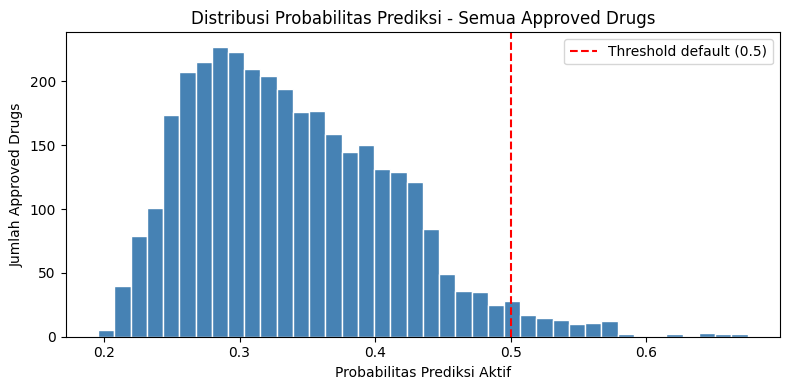

In [ ]:
print('Statistik deskriptif probabilitas prediksi:')
print(screening_df['pred_proba_active'].describe())

print('\nJumlah molekul per rentang probabilitas:')
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
screening_df['proba_bin'] = pd.cut(screening_df['pred_proba_active'], bins=bins, include_lowest=True)
print(screening_df['proba_bin'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
plt.hist(screening_df['pred_proba_active'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(0.5, color='red', linestyle='--', label='Threshold default (0.5)')
plt.xlabel('Probabilitas Prediksi Aktif')
plt.ylabel('Jumlah Approved Drugs')
plt.title('Distribusi Probabilitas Prediksi - Semua Approved Drugs')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit import RDLogger
from tqdm import tqdm

RDLogger.DisableLog('rdApp.*')

def smiles_to_ecfp_bitvect(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

# Generate bitvect (bukan numpy array) untuk training set - dipakai fungsi similarity RDKit
print('Menghitung fingerprint training set untuk similarity search...')
training_bitvects = []
for smiles in tqdm(training_metadata_df['canonical_smiles'], desc='Training fingerprints'):
    bv = smiles_to_ecfp_bitvect(smiles)
    training_bitvects.append(bv)

training_labels = training_metadata_df['label'].values
valid_training_mask = [bv is not None for bv in training_bitvects]
training_bitvects_valid = [bv for bv, ok in zip(training_bitvects, valid_training_mask) if ok]
training_labels_valid = training_labels[valid_training_mask]

print(f'Training fingerprints valid: {len(training_bitvects_valid)}')

Menghitung fingerprint training set untuk similarity search...


Training fingerprints: 100%|██████████| 2034/2034 [00:00<00:00, 2044.54it/s]

Training fingerprints valid: 2034


In [ ]:
def max_similarity_to_training(smiles, training_bitvects, training_labels):
    """
    Menghitung similarity Tanimoto tertinggi antara satu molekul dan seluruh training set.
    Mengembalikan (max_similarity, label_molekul_training_paling_mirip).
    """
    query_bv = smiles_to_ecfp_bitvect(smiles)
    if query_bv is None:
        return np.nan, np.nan
    sims = DataStructs.BulkTanimotoSimilarity(query_bv, training_bitvects)
    max_idx = int(np.argmax(sims))
    return sims[max_idx], training_labels[max_idx]

# Untuk efisiensi, hitung similarity hanya untuk top-N kandidat dulu (bisa diperluas kalau perlu)
TOP_N_FOR_SIMILARITY = 200
top_candidates = screening_df.head(TOP_N_FOR_SIMILARITY).copy()

max_sims = []
nearest_labels = []
for smiles in tqdm(top_candidates['canonical_smiles'], desc='Menghitung similarity ke training set'):
    sim, label = max_similarity_to_training(smiles, training_bitvects_valid, training_labels_valid)
    max_sims.append(sim)
    nearest_labels.append(label)

top_candidates['max_tanimoto_to_training'] = max_sims
top_candidates['nearest_training_label'] = nearest_labels

Menghitung similarity ke training set: 100%|██████████| 200/200 [00:00<00:00, 546.81it/s]


In [ ]:
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import FilterCatalog
from rdkit.Chem.FilterCatalog import FilterCatalogParams

def lipinski_check(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return pd.Series({'MW': np.nan, 'LogP': np.nan, 'HBD': np.nan, 'HBA': np.nan, 'lipinski_violations': np.nan})
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    violations = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    return pd.Series({'MW': mw, 'LogP': logp, 'HBD': hbd, 'HBA': hba, 'lipinski_violations': violations})

lipinski_results = top_candidates['canonical_smiles'].apply(lipinski_check)
top_candidates = pd.concat([top_candidates, lipinski_results], axis=1)

In [ ]:
# Setup PAINS filter catalog dari RDKit
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog.FilterCatalog(params)

def check_pains(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    match = pains_catalog.GetFirstMatch(mol)
    return match.GetDescription() if match else None

top_candidates['pains_alert'] = top_candidates['canonical_smiles'].apply(check_pains)

n_pains = top_candidates['pains_alert'].notna().sum()
print(f'Jumlah kandidat dengan PAINS alert: {n_pains} dari {len(top_candidates)}')

Jumlah kandidat dengan PAINS alert: 9 dari 200


In [ ]:
SIMILARITY_THRESHOLD = 0.2
shortlist = top_candidates[
    (top_candidates['pred_label'] == 1) &
    (top_candidates['max_tanimoto_to_training'] >= SIMILARITY_THRESHOLD) &
    (top_candidates['pains_alert'].isna())
].copy()

shortlist = shortlist.sort_values('pred_proba_active', ascending=False).reset_index(drop=True)

print(f'Jumlah kandidat di shortlist akhir: {len(shortlist)}')
display_cols = [
    'molecule_chembl_id', 'pref_name', 'pred_proba_active',
    'max_tanimoto_to_training', 'nearest_training_label',
    'MW', 'LogP', 'lipinski_violations', 'pains_alert'
]
shortlist[display_cols].head(30)

Jumlah kandidat di shortlist akhir: 75


,molecule_chembl_id,pref_name,pred_proba_active,max_tanimoto_to_training,nearest_training_label,MW,LogP,lipinski_violations,pains_alert
0,CHEMBL5314588,PERFLUOROHEXYLOCTANE,0.674793,0.363636,0,432.264,7.47580,1.0,None
1,CHEMBL1200694,SEVOFLURANE,0.652300,0.205882,1,200.053,2.42320,0.0,None
2,CHEMBL2110725,VINFLUNINE,0.589225,0.201439,0,816.943,5.07870,3.0,None
3,CHEMBL1200412,NANDROLONE PHENPROPIONATE,0.572785,0.281690,0,406.566,5.67280,1.0,None
4,CHEMBL25,ASPIRIN,0.571597,1.000000,1,180.159,1.31010,0.0,None
5,CHEMBL3989933,ETRASIMOD ARGININE,0.570860,0.298969,0,631.696,5.58937,3.0,None
6,CHEMBL1675,VITAMIN A PALMITATE,0.570339,0.394737,0,524.874,11.54250,2.0,None
7,CHEMBL1200542,DESOXYCORTICOSTERONE ACETATE,0.568701,0.259259,0,372.505,4.26670,0.0,None
8,CHEMBL1200335,TESTOSTERONE ENANTHATE,0.567924,0.296296,0,400.603,6.40050,1.0,None
9,CHEMBL1084172,VILANTEROL TRIFENATATE,0.566836,0.277108,0,774.782,8.71370,2.0,None


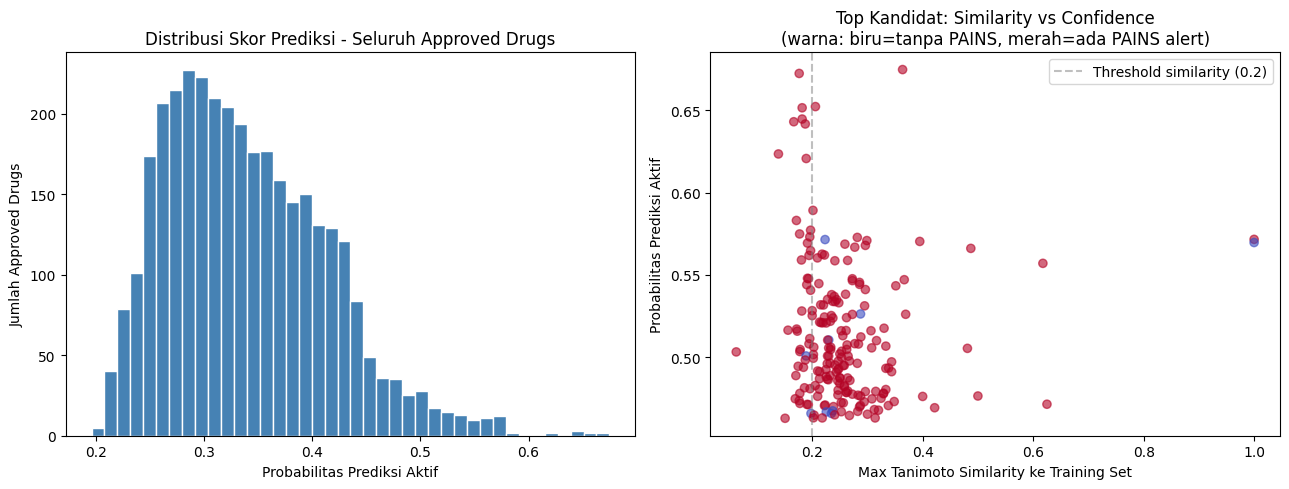

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(screening_df['pred_proba_active'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Probabilitas Prediksi Aktif')
axes[0].set_ylabel('Jumlah Approved Drugs')
axes[0].set_title('Distribusi Skor Prediksi - Seluruh Approved Drugs')

axes[1].scatter(
    top_candidates['max_tanimoto_to_training'],
    top_candidates['pred_proba_active'],
    alpha=0.6, c=top_candidates['pains_alert'].isna(), cmap='coolwarm'
)
axes[1].axvline(SIMILARITY_THRESHOLD, color='gray', linestyle='--', alpha=0.5, label=f'Threshold similarity ({SIMILARITY_THRESHOLD})')
axes[1].set_xlabel('Max Tanimoto Similarity ke Training Set')
axes[1].set_ylabel('Probabilitas Prediksi Aktif')
axes[1].set_title('Top Kandidat: Similarity vs Confidence\n(warna: biru=tanpa PAINS, merah=ada PAINS alert)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'screening_overview.png'), dpi=150)
plt.show()

In [ ]:
full_results_path = os.path.join(RESULTS_DIR, 'screening_all_approved_drugs.csv')
screening_df.to_csv(full_results_path, index=False)

top_candidates_path = os.path.join(RESULTS_DIR, 'screening_top_candidates_with_similarity.csv')
top_candidates.to_csv(top_candidates_path, index=False)

shortlist_path = os.path.join(RESULTS_DIR, 'screening_shortlist_final.csv')
shortlist.to_csv(shortlist_path, index=False)

print('Hasil lengkap (semua approved drugs) tersimpan di:', full_results_path)
print('Top kandidat + similarity analysis tersimpan di:', top_candidates_path)
print('Shortlist final tersimpan di:', shortlist_path)

Hasil lengkap (semua approved drugs) tersimpan di: /content/drive/MyDrive/pla2/results/screening_all_approved_drugs.csv
Top kandidat + similarity analysis tersimpan di: /content/drive/MyDrive/pla2/results/screening_top_candidates_with_similarity.csv
Shortlist final tersimpan di: /content/drive/MyDrive/pla2/results/screening_shortlist_final.csv
